<a href="https://colab.research.google.com/github/io-uty/skt-pytorch/blob/main/Grad_CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grad‑CAM을 이용한 CNN 예측 근거 시각화


#### Colab 실행환경 확인

In [1]:
import torch # tensor연산과 딥러닝 모델 실행을 위해
import torchvision # 이미지모델, 전처리, 데이터셋 제공

print("torch version :", torch.__version__)
print("torchvision version:", torchvision.__version__)
print("CUDA available :", torch.cuda.is_available())

# GPU가 있으면 cuda, 없으면 cpu를 사용함
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device :", device)

torch version : 2.11.0+cu128
torchvision version: 0.26.0+cu128
CUDA available : True
device : cuda


#### library 불러오기
- 이미지 다운로드,읽기
- Pretrained CNN 모델 불러오기
- 입력 이미지 전처리
- heatmap 시각화
- feature map과 gradient 저장

In [2]:
import os # 파일 경로와 존재 여부 확인에 사용
import urllib.request # 예제 이미지를 URL에서 내려받는 데 사용
from pathlib import Path # 경로를 객체처럼 다루기 위해 사용
import numpy as np # 이미지와 heatmap을 배열 형태로 처리하는 데 사용
import pandas as pd # top‑k 예측 결과를 표로 정리하는 데 사용
import matplotlib.pyplot as plt # 이미지와 heatmap을 시각화하는 데 사용
from PIL import Image # 이미지 파일을 읽고 RGB 형식으로 변환하는 데 사용
import torch.nn.functional as F # interpolate, ReLU 등 tensor 연산 함수 사용
from torchvision import transforms # 이미지 resize, crop 등을 구성하는 데 사용
from torchvision.models import resnet18, ResNet18_Weights # pretrained ResNet18 불러오기
# 실험 재현성을 높이기 위한 난수 고정
# 본 실습에서는 pretrained model의 inference가 중심이므로 큰 영향은 없지만,
# 일반적인 실험 코드에서는 난수 고정이 결과 비교에 중요함
torch.manual_seed(42)
np.random.seed(42)

#### ImageNet pretrained ResNet18모델 불러오기
- model구조변경하지 않고 activation과 gradient만 이용

In [3]:
# ImageNet pretrained weight 설정
# DEFAULT는 torchvision에서 권장하는 기본 pretrained weight를 의미함
weights = ResNet18_Weights.DEFAULT
# pretrained ResNet18 모델을 생성함
# weights를 지정하면 ImageNet 학습 가중치가 자동으로 다운로드됨
model = resnet18(weights=weights)
# 모델을 GPU 또는 CPU로 이동함
model = model.to(device)
# Dropout, BatchNorm 등이 평가 모드로 동작하도록 설정함
# Grad‑CAM 계산에서도 모델은 보통 eval 모드로 둠
model.eval()
# ImageNet 클래스 이름 목록을 불러옴
# categories[i]는 i번째 ImageNet 클래스의 문자열 이름임
categories = weights.meta["categories"]
print("number of ImageNet classes:", len(categories))
print("first 10 classes:", categories[:10])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 313MB/s]


number of ImageNet classes: 1000
first 10 classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


#### 예제 이미지 준비

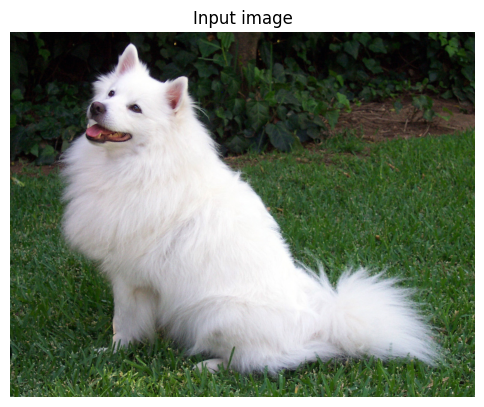

original image size: (1546, 1213)


In [5]:
# 예제 이미지 URL
# 인터넷이 연결된 Colab 환경에서 실행됨
IMAGE_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
# 저장할 이미지 경로
image_path = Path("dog.jpg")
# 이미지 파일이 현재 작업 폴더에 없으면 다운로드함
if not image_path.exists():
  urllib.request.urlretrieve(IMAGE_URL, image_path)
# 이미지를 RGB 형식으로 읽음
# pretrained ImageNet 모델은 3채널 RGB 입력을 기대함
image = Image.open(image_path).convert("RGB")
# 원본 이미지 확인
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input image")
plt.show()
print("original image size:", image.size)

#### 입력 이미지 전처리
- shape은 R^Bx3x224x224

In [6]:
# pretrained weight에 포함된 공식 전처리 함수를 사용함
# Resize, CenterCrop, ToTensor, Normalize가 포함됨
preprocess = weights.transforms()
# 시각화를 위해 전처리 과정 중 Resize와 CenterCrop만 별도로 적용한 이미지도 준비함
# Normalize가 적용된 tensor는 사람이 직접 보기 어려우므로, 원본 시각화용 이미지를 따로 둠
visual_transform = transforms.Compose([
transforms.Resize(256), # 짧은 변을 256 크기로 조정함
transforms.CenterCrop(224), # 중앙 영역을 224 x 224로 자름
])
# 모델 입력용 tensor 생성
# preprocess(image)의 shape: [3, 224, 224]
# unsqueeze(0)을 적용하여 batch 차원을 추가함: [1, 3, 224, 224]
input_tensor = preprocess(image).unsqueeze(0).to(device)
# 시각화용 PIL 이미지 생성
vis_image = visual_transform(image)
print("input tensor shape:", tuple(input_tensor.shape))
print("visual image size :", vis_image.size)

input tensor shape: (1, 3, 224, 224)
visual image size : (224, 224)


#### 모델 예측 결과 확인
- 이미지를 어떤 클래스로 분류하는지? : R^BxC

In [8]:
# 예측 결과만 확인할 때는 gradient가 필요하지 않으므로 no_grad()를 사용함
# Grad‑CAM 계산 셀에서는 gradient가 필요하므로 no_grad()를 사용하지 않음
with torch.no_grad():
  logits = model(input_tensor) # logits shape: [1, 1000]
  probabilities = torch.softmax(logits, dim=1) # class 방향으로 softmax 적용
# 확률이 큰 상위 5개 클래스를 선택함
top5_prob, top5_idx = torch.topk(probabilities, k=5, dim=1)
# 결과를 표로 정리함
top5_table = pd.DataFrame({
"rank": list(range(1, 6)),
"class_index": top5_idx[0].cpu().numpy(),
"class_name": [categories[int(i)] for i in top5_idx[0].cpu().numpy()],
"probability": top5_prob[0].cpu().numpy(),
})
display(top5_table)
print("logits shape:", tuple(logits.shape))

,rank,class_index,class_name,probability
0,1,258,Samoyed,0.884795
1,2,279,Arctic fox,0.045754
2,3,270,white wolf,0.044178
3,4,259,Pomeranian,0.005619
4,5,257,Great Pyrenees,0.004658


logits shape: (1, 1000)


#### PyTorch hook을 이용한 activation과 gradient 저장
- 1. register_forward_hook: target layer의 forward 출력 activation을 저장함.
- 2. Tensor.register_hook: activation tensor에 대한 gradient가 계산될 때 gradient를 저장함.
이 방식은 모델 구조를 직접 수정하지 않고도 중간 feature map과 gradient를 얻을 수 있다

In [11]:
class GradCAM:
    # PyTorch 모델에 대해 Grad‑CAM heatmap을 계산하는 클래스.
    def __init__(self, model, target_layer):
        # Grad‑CAM을 적용할 모델을 저장함
        self.model = model
        # activation과 gradient를 얻을 target layer를 저장함
        self.target_layer = target_layer
        # forward pass에서 저장될 activation tensor
        self.activations = None
        # backward pass에서 저장될 gradient tensor
        self.gradients = None
        # target layer에 forward hook을 등록함
        # forward hook은 target layer가 출력을 만들 때마다 호출됨
        self.forward_handle = self.target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, input, output):
        # output은 target layer의 activation임
        # ResNet18 layer4[‑1].conv2의 경우 shape은 보통 [B, 512, 7, 7]임
        self.activations = output
        # output tensor에 gradient hook을 등록함
        # backward가 수행되어 output에 대한 gradient가 계산되면 _save_gradient가 호출됨
        output.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        # target class score를 activation에 대해 미분한 gradient를 저장함
        self.gradients = grad

    def remove(self):
        # 반복 실행 시 hook이 중복 등록되지 않도록 사용 후 제거함
        self.forward_handle.remove()

    def __call__(self, input_tensor, class_idx=None):
        # 이전 gradient가 남아 있지 않도록 모델의 gradient buffer를 초기화함
        self.model.zero_grad(set_to_none=True)
        # Grad‑CAM 계산에서는 gradient가 필요하므로 torch.no_grad()를 사용하지 않음
        logits = self.model(input_tensor)

        # class_idx가 지정되지 않으면 모델이 가장 높게 예측한 클래스를 target으로 사용함
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        # target class logit을 선택함
        # batch size가 1인 실습이므로 logits[:, class_idx]의 합을 scalar score로 사용함
        score = logits[:, class_idx].sum()

        # target class score를 기준으로 backward pass를 수행함
        # 이 과정에서 target layer activation에 대한 gradient가 계산됨
        score.backward()

        # hook으로 저장된 activation과 gradient를 가져옴
        activations = self.activations.detach() # shape: [B, K, H, W]
        gradients = self.gradients.detach() # shape: [B, K, H, W]

        # Grad‑CAM 가중치 alpha_k^c 계산
        # 각 channel별 gradient를 H, W 방향으로 평균냄
        weights = gradients.mean(dim=(2, 3), keepdim=True) # shape: [B, K, 1, 1]

        # channel 방향으로 weighted sum을 계산함
        # (weights * activations)의 shape은 [B, K, H, W]
        # sum(dim=1)을 통해 [B, H, W]의 class activation map을 얻음
        cam = (weights * activations).sum(dim=1) # shape: [B, H, W]

        # target class에 양의 방향으로 기여한 영역만 남김
        cam = torch.relu(cam)

        # 원본 입력 이미지 해상도에 맞도록 bilinear interpolation 수행
        cam = F.interpolate(
            cam.unsqueeze(1), # [B, 1, H, W]
            size=input_tensor.shape[-2:], # [224, 224]
            mode="bilinear",
            align_corners=False,
        ).squeeze(1) # [B, 224, 224]

        # heatmap 값을 0~1 범위로 정규화함
        cam_min = cam.flatten(start_dim=1).min(dim=1)[0].view(-1, 1, 1)
        cam_max = cam.flatten(start_dim=1).max(dim=1)[0].view(-1, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam, logits, class_idx

#### Grad‑CAM heatmap 생성 함수
- Grad-CAM 객체 생성 및 heatmap 계산, hook 제거

In [14]:
def generate_gradcam(model, target_layer, input_tensor, class_idx=None):
  gradcam = GradCAM(model=model, target_layer=target_layer)
# heatmap 계산
  cam, logits, used_class_idx = gradcam(input_tensor, class_idx=class_idx)
# 수업 중 shape 확인을 위해 activation과 gradient shape을 저장함
  activation_shape = tuple(gradcam.activations.shape)
  gradient_shape = tuple(gradcam.gradients.shape)
# hook 중복 등록 방지를 위해 제거함
  gradcam.remove()
  return cam, logits, used_class_idx, activation_shape, gradient_shape
def make_overlay_image(pil_image, cam_tensor, alpha=0.45, cmap_name="jet"):
# PIL 이미지를 numpy 배열로 변환하고 0~1 범위로 정규화함
  image_np = np.array(pil_image).astype(np.float32) / 255.0
# cam_tensor는 [224, 224] 형태라고 가정함
  cam_np = cam_tensor.detach().cpu().numpy()
# heatmap 색상을 적용함
# 반환 배열의 마지막 채널 alpha는 제거하고 RGB만 사용함
  heatmap_np = plt.get_cmap(cmap_name)(cam_np)[..., :3]
# 원본 이미지와 heatmap을 alpha 비율로 합성함
  overlay_np = (1 - alpha) * image_np + alpha * heatmap_np
# 값 범위를 0~1로 제한함
  overlay_np = np.clip(overlay_np, 0.0, 1.0)
  return image_np, heatmap_np, overlay_np
def show_gradcam_result(pil_image, cam_tensor, class_name, probability=None):
# 원본 이미지, heatmap, 합성 이미지를 생성함
  image_np, heatmap_np, overlay_np = make_overlay_image(pil_image, cam_tensor)
# 제목 문자열 구성
  if probability is None:
    title = f"Grad-CAM target: {class_name}"
  else:
    title = f"Grad-CAM target: {class_name} ({probability:.4f})"
# 세 개의 이미지를 나란히 출력함
  fig, axes = plt.subplots(1, 3, figsize=(15, 5))
  axes[0].imshow(image_np)
  axes[0].set_title("Input")
  axes[0].axis("off")
  axes[1].imshow(heatmap_np)
  axes[1].set_title("Grad-CAM heatmap")
  axes[1].axis("off")
  axes[2].imshow(overlay_np)
  axes[2].set_title(title)
  axes[2].axis("off")
  plt.tight_layout()
  plt.show()

#### 마지막 convolution layer에 대한 Grad‑CAM 계산
- ResNet18의 마지막 convolution feature map은 model.layer4[‑1].conv2에서 얻을 수 있다.
- 이 layer의 출력은 이미지의 세부
픽셀보다는 객체 수준의 의미 정보를 더 많이 포함하면서도 7 × 7 수준의 공간 정보를 유지한다

target class index: 258
target class name : Samoyed
target probability: 0.8847945332527161
activation shape : (1, 512, 7, 7)
gradient shape : (1, 512, 7, 7)
cam shape : (1, 224, 224)


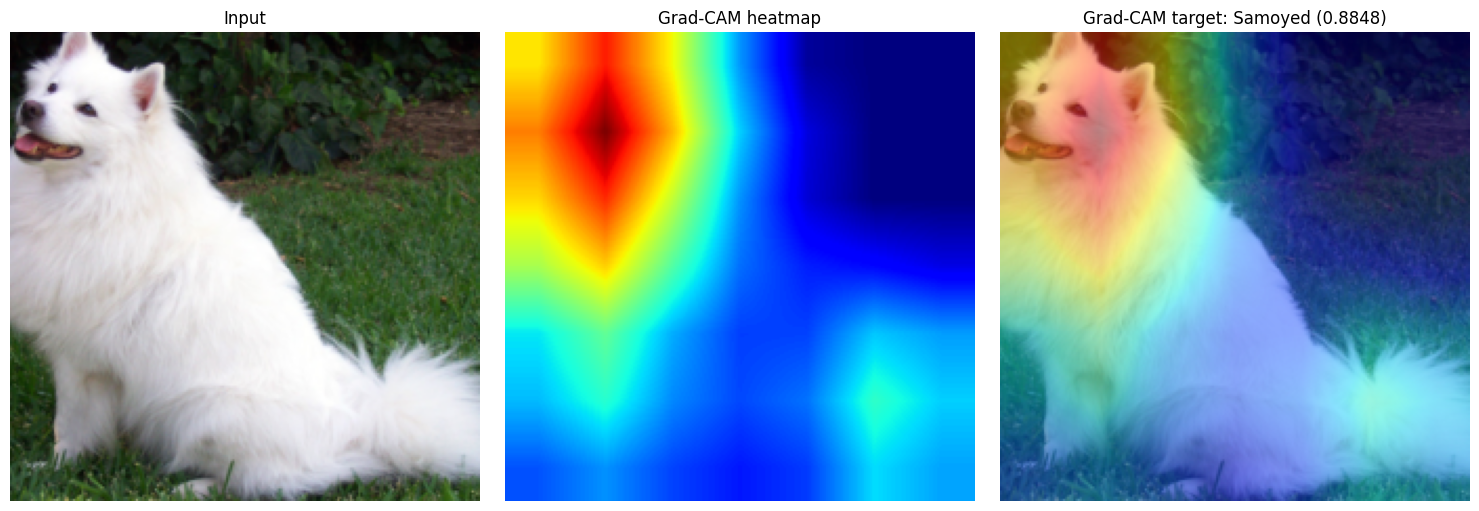

In [16]:
# ResNet18의 마지막 residual block 안에 있는 마지막 convolution layer를 target으로 지정함
target_layer = model.layer4[-1].conv2
# 모델이 가장 높게 예측한 class를 target으로 Grad‑CAM을 계산함
cam, gradcam_logits, used_class_idx, activation_shape, gradient_shape = generate_gradcam(
model=model,
target_layer=target_layer,
input_tensor=input_tensor,
class_idx=None,
)
# target class의 softmax probability를 계산함
gradcam_prob = torch.softmax(gradcam_logits, dim=1)[0, used_class_idx].item()
used_class_name = categories[used_class_idx]
print("target class index:", used_class_idx)
print("target class name :", used_class_name)
print("target probability:", gradcam_prob)
print("activation shape :", activation_shape)
print("gradient shape :", gradient_shape)
print("cam shape :", tuple(cam.shape))
# Grad‑CAM 결과 시각화
show_gradcam_result(
pil_image=vis_image,
cam_tensor=cam[0],
class_name=used_class_name,
probability=gradcam_prob,
)

- alpha 블렌딩